# Chapter 3 - Monte Carlo Simulation and Shapley Attribution

**Dissertation:** Understanding Health Insurance Cost Predictions Using Deep Neural Networks, Monte Carlo Simulation and Shapley Values  
**Author:** Thabang Bongani Junior Baloyi (2015015486)  
**Supervisor:** Mr J. Blomerous (FASSA)  

This notebook implements Layers 2 and 3 of the DNN-MC-Shapley framework (Chapter 2, Section 2.2):  
1. **Parametric Monte Carlo Simulation** (Algorithm 3.1) - generates synthetic policyholder profiles from fitted marginal distributions and scores them through the trained DNN.  
2. **Residual-Augmented MC Sensitivity** (Algorithm 3.2) - incorporates model uncertainty via centred training residuals.  
3. **Shapley Value Attribution** (Sections 3.7-3.8) - decomposes predictions into additive feature contributions using SHAP, both globally and conditional on high-cost thresholds.

## 1. Setup and Model Loading

In [1]:
import os
import copy
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import shap
from scipy import stats

warnings.filterwarnings('ignore')

# Plot style - consistent with chapter3_dnn_training.ipynb
sns.set_style('white')
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.grid': False,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12
})

# Figures output directory
FIG_DIR = '/Users/baloyithabangbonganijunior/Downloads/chapter3_figures/'
os.makedirs(FIG_DIR, exist_ok=True)

DATA_DIR = '/Users/baloyithabangbonganijunior/Downloads/'

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'PyTorch version : {torch.__version__}')
print(f'SHAP version    : {shap.__version__}')
print(f'Device          : {DEVICE}')
print(f'Seed            : {SEED}')

PyTorch version : 2.12.0
SHAP version    : 0.51.0
Device          : mps
Seed            : 42


/Users/baloyithabangbonganijunior/.venv_dnn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1.1 Reconstruct and Load the Trained DNN

In [2]:
class FunnelDNN(nn.Module):
    """Feed-forward DNN with funnel architecture (bias-free)."""

    def __init__(self, input_dim=22, hidden_layers=[256, 128, 64, 32, 16],
                 activation='CELU'):
        super(FunnelDNN, self).__init__()

        act_map = {
            'CELU': nn.CELU(),
            'GELU': nn.GELU(),
            'Tanh': nn.Tanh()
        }
        act_fn = act_map[activation]

        layers = []
        prev_dim = input_dim
        for h_dim in hidden_layers:
            layers.append(nn.Linear(prev_dim, h_dim, bias=False))
            layers.append(copy.deepcopy(act_fn))
            prev_dim = h_dim
        layers.append(nn.Linear(prev_dim, 1, bias=False))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


# Load checkpoint
checkpoint = torch.load(DATA_DIR + 'chapter3_final_model.pth',
                        map_location='cpu', weights_only=False)

arch = checkpoint['architecture']
model = FunnelDNN(
    input_dim=arch['input_dim'],
    hidden_layers=arch['hidden_layers'],
    activation=arch['activation']
)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
model = model.to(DEVICE)

# Extract standardisation parameters
std_params = checkpoint['standardisation']
X_mean = std_params['X_mean']
X_std = std_params['X_std']
y_mean = std_params['y_mean']
y_std = std_params['y_std']

FEATURES = checkpoint['features']

print(f'Model loaded: {arch}')
print(f'Parameters   : {sum(p.numel() for p in model.parameters()):,}')
print(f'y_mean       : {y_mean:.2f}')
print(f'y_std        : {y_std:.2f}')
print(f'Features ({len(FEATURES)}): {FEATURES}')

Model loaded: {'input_dim': 22, 'hidden_layers': [256, 128, 64, 32, 16], 'activation': 'CELU', 'bias': False}
Parameters   : 49,168
y_mean       : 16739.52
y_std        : 4415.99
Features (22): ['age', 'gender', 'bmi', 'children', 'smoker', 'region_southwest', 'region_northwest', 'region_southeast', 'medical_history_Heart_disease', 'medical_history_High_blood_pressure', 'medical_history_Diabetes', 'family_medical_history_Heart_disease', 'family_medical_history_High_blood_pressure', 'family_medical_history_Diabetes', 'exercise_frequency_Occasionally', 'exercise_frequency_Frequently', 'exercise_frequency_Never', 'occupation_Student', 'occupation_Blue_collar', 'occupation_White_collar', 'coverage_level_Standard', 'coverage_level_Premium']


### 1.2 Load Training Data

In [3]:
# Raw data for marginal distribution estimation
df_raw = pd.read_csv(DATA_DIR + 'insurance_dataset.csv')
df_raw['medical_history'] = df_raw['medical_history'].fillna('None')
df_raw['family_medical_history'] = df_raw['family_medical_history'].fillna('None')
print(f'Raw dataset: {df_raw.shape}')

# Encoded training data for SHAP background
df_train_encoded = pd.read_csv(DATA_DIR + 'model_ready_charges_train_20260517_115748.csv')
TRAIN_FEATURES = [c for c in df_train_encoded.columns if c != 'charges']
X_train_raw = df_train_encoded[TRAIN_FEATURES].values.astype(np.float32)
y_train_raw = df_train_encoded['charges'].values.astype(np.float32)

# Standardised training inputs (for residual computation)
X_train_std = ((X_train_raw - X_mean) / X_std).astype(np.float32)

print(f'Encoded training data: {df_train_encoded.shape}')
print(f'Feature order matches checkpoint: {TRAIN_FEATURES == FEATURES}')

Raw dataset: (1000000, 12)


Encoded training data: (524288, 23)
Feature order matches checkpoint: True


### 1.3 DNN Scoring Helper

In [4]:
def score_dnn(X_encoded_raw, standardise=True, denormalise=True):
    """
    Score profiles through the DNN.

    Parameters
    ----------
    X_encoded_raw : np.ndarray, shape (n, 22)
        Reference-category encoded features (not yet standardised).
    standardise : bool
        If True, apply (X - X_mean) / X_std before scoring.
    denormalise : bool
        If True, convert output from normalised to original Rand scale.

    Returns
    -------
    np.ndarray, shape (n,)
    """
    X = X_encoded_raw.astype(np.float32)
    if standardise:
        X = (X - X_mean) / X_std
    X_t = torch.tensor(X, dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        preds = model(X_t).cpu().numpy().flatten()
    if denormalise:
        preds = preds * y_std + y_mean
    return preds


# Sanity check: score first 5 training rows
test_preds = score_dnn(X_train_raw[:5])
print('Sanity check (first 5 training predictions):')
for i in range(5):
    print(f'  Actual: {y_train_raw[i]:10.2f}  Predicted: {test_preds[i]:10.2f}')

Sanity check (first 5 training predictions):
  Actual:   14270.54  Predicted:   14267.00
  Actual:   16226.64  Predicted:   16613.50
  Actual:   16284.01  Predicted:   16318.38
  Actual:   22749.10  Predicted:   22451.65
  Actual:   13783.96  Predicted:   14220.87


## 2. Parametric Monte Carlo Simulation (Algorithm 3.1)

Fit marginal distributions from the training data and generate $B = 10\,000$ synthetic policyholder profiles.  
Each profile is encoded using the same reference-category scheme as the training data, standardised, scored through the DNN, and de-normalised to the original Rand scale.

**Marginal distributions:**
- `age`: DiscreteUniform(18, 65)
- `bmi`: ContinuousUniform(18, 50)
- `children`: DiscreteUniform(0, 5)
- `gender`: Bernoulli($p_{\text{male}}$ from training data)
- `smoker`: Bernoulli($p_{\text{yes}}$ from training data)
- `region`: Categorical(4 levels, training proportions), reference = northeast
- `medical_history`: Categorical(4 levels incl. None), reference = None
- `family_medical_history`: Categorical(4 levels incl. None), reference = None
- `exercise_frequency`: Categorical(4 levels), reference = Rarely
- `occupation`: Categorical(4 levels), reference = Unemployed
- `coverage_level`: Categorical(3 levels), reference = Basic

In [5]:
B = 10_000  # Number of MC samples

# --- Estimate marginal parameters from raw training data ---
p_male = (df_raw['gender'] == 'male').mean()
p_smoker = (df_raw['smoker'] == 'yes').mean()

region_levels = ['northeast', 'northwest', 'southeast', 'southwest']
region_probs = np.array([(df_raw['region'] == r).mean() for r in region_levels])

med_hist_levels = ['None', 'Heart disease', 'High blood pressure', 'Diabetes']
med_hist_probs = np.array([(df_raw['medical_history'] == m).mean() for m in med_hist_levels])

fam_hist_levels = ['None', 'Heart disease', 'High blood pressure', 'Diabetes']
fam_hist_probs = np.array([(df_raw['family_medical_history'] == f).mean() for f in fam_hist_levels])

exercise_levels = ['Rarely', 'Occasionally', 'Frequently', 'Never']
exercise_probs = np.array([(df_raw['exercise_frequency'] == e).mean() for e in exercise_levels])

occ_levels = ['Unemployed', 'Student', 'Blue collar', 'White collar']
occ_probs = np.array([(df_raw['occupation'] == o).mean() for o in occ_levels])

cov_levels = ['Basic', 'Standard', 'Premium']
cov_probs = np.array([(df_raw['coverage_level'] == c).mean() for c in cov_levels])

print('Marginal distribution parameters:')
print(f'  p_male   = {p_male:.4f}')
print(f'  p_smoker = {p_smoker:.4f}')
print(f'  region   = {dict(zip(region_levels, region_probs.round(4)))}')
print(f'  med_hist = {dict(zip(med_hist_levels, med_hist_probs.round(4)))}')
print(f'  fam_hist = {dict(zip(fam_hist_levels, fam_hist_probs.round(4)))}')
print(f'  exercise = {dict(zip(exercise_levels, exercise_probs.round(4)))}')
print(f'  occup    = {dict(zip(occ_levels, occ_probs.round(4)))}')
print(f'  coverage = {dict(zip(cov_levels, cov_probs.round(4)))}')

Marginal distribution parameters:
  p_male   = 0.5001
  p_smoker = 0.5001
  region   = {'northeast': np.float64(0.2503), 'northwest': np.float64(0.2499), 'southeast': np.float64(0.2496), 'southwest': np.float64(0.2501)}
  med_hist = {'None': np.float64(0.2508), 'Heart disease': np.float64(0.2501), 'High blood pressure': np.float64(0.2498), 'Diabetes': np.float64(0.2493)}
  fam_hist = {'None': np.float64(0.2504), 'Heart disease': np.float64(0.25), 'High blood pressure': np.float64(0.2498), 'Diabetes': np.float64(0.2497)}
  exercise = {'Rarely': np.float64(0.2505), 'Occasionally': np.float64(0.2504), 'Frequently': np.float64(0.2497), 'Never': np.float64(0.2494)}
  occup    = {'Unemployed': np.float64(0.2506), 'Student': np.float64(0.2503), 'Blue collar': np.float64(0.2498), 'White collar': np.float64(0.2493)}
  coverage = {'Basic': np.float64(0.3335), 'Standard': np.float64(0.3335), 'Premium': np.float64(0.333)}


In [6]:
def generate_mc_profiles(n, rng):
    """
    Generate n raw MC profiles from fitted marginal distributions.

    Returns
    -------
    df_mc : pd.DataFrame with columns matching the raw dataset variables.
    """
    age = rng.integers(18, 66, size=n)  # DiscreteUniform(18, 65)
    bmi = rng.uniform(18.0, 50.0, size=n)  # ContinuousUniform(18, 50)
    children = rng.integers(0, 6, size=n)  # DiscreteUniform(0, 5)
    gender = rng.choice(['male', 'female'], size=n, p=[p_male, 1 - p_male])
    smoker = rng.choice(['yes', 'no'], size=n, p=[p_smoker, 1 - p_smoker])
    region = rng.choice(region_levels, size=n, p=region_probs)
    medical_history = rng.choice(med_hist_levels, size=n, p=med_hist_probs)
    family_medical_history = rng.choice(fam_hist_levels, size=n, p=fam_hist_probs)
    exercise_frequency = rng.choice(exercise_levels, size=n, p=exercise_probs)
    occupation = rng.choice(occ_levels, size=n, p=occ_probs)
    coverage_level = rng.choice(cov_levels, size=n, p=cov_probs)

    return pd.DataFrame({
        'age': age, 'gender': gender, 'bmi': bmi, 'children': children,
        'smoker': smoker, 'region': region, 'medical_history': medical_history,
        'family_medical_history': family_medical_history,
        'exercise_frequency': exercise_frequency,
        'occupation': occupation, 'coverage_level': coverage_level
    })


def encode_profiles(df_mc):
    """
    Apply reference-category encoding to match the 22 model features.

    Encoding scheme (reference category omitted as all-zeros):
    - gender: male=1, female=0
    - smoker: yes=1, no=0
    - region: dummies for southwest, northwest, southeast (ref=northeast)
    - medical_history: dummies for Heart_disease, High_blood_pressure, Diabetes (ref=None)
    - family_medical_history: dummies for Heart_disease, High_blood_pressure, Diabetes (ref=None)
    - exercise_frequency: dummies for Occasionally, Frequently, Never (ref=Rarely)
    - occupation: dummies for Student, Blue_collar, White_collar (ref=Unemployed)
    - coverage_level: dummies for Standard, Premium (ref=Basic)

    Returns
    -------
    np.ndarray, shape (n, 22)
    """
    n = len(df_mc)
    X = np.zeros((n, 22), dtype=np.float32)

    X[:, 0] = df_mc['age'].values
    X[:, 1] = (df_mc['gender'] == 'male').astype(np.float32).values
    X[:, 2] = df_mc['bmi'].values
    X[:, 3] = df_mc['children'].values
    X[:, 4] = (df_mc['smoker'] == 'yes').astype(np.float32).values

    # region dummies (ref = northeast)
    X[:, 5] = (df_mc['region'] == 'southwest').astype(np.float32).values
    X[:, 6] = (df_mc['region'] == 'northwest').astype(np.float32).values
    X[:, 7] = (df_mc['region'] == 'southeast').astype(np.float32).values

    # medical_history dummies (ref = None)
    X[:, 8] = (df_mc['medical_history'] == 'Heart disease').astype(np.float32).values
    X[:, 9] = (df_mc['medical_history'] == 'High blood pressure').astype(np.float32).values
    X[:, 10] = (df_mc['medical_history'] == 'Diabetes').astype(np.float32).values

    # family_medical_history dummies (ref = None)
    X[:, 11] = (df_mc['family_medical_history'] == 'Heart disease').astype(np.float32).values
    X[:, 12] = (df_mc['family_medical_history'] == 'High blood pressure').astype(np.float32).values
    X[:, 13] = (df_mc['family_medical_history'] == 'Diabetes').astype(np.float32).values

    # exercise_frequency dummies (ref = Rarely)
    X[:, 14] = (df_mc['exercise_frequency'] == 'Occasionally').astype(np.float32).values
    X[:, 15] = (df_mc['exercise_frequency'] == 'Frequently').astype(np.float32).values
    X[:, 16] = (df_mc['exercise_frequency'] == 'Never').astype(np.float32).values

    # occupation dummies (ref = Unemployed)
    X[:, 17] = (df_mc['occupation'] == 'Student').astype(np.float32).values
    X[:, 18] = (df_mc['occupation'] == 'Blue collar').astype(np.float32).values
    X[:, 19] = (df_mc['occupation'] == 'White collar').astype(np.float32).values

    # coverage_level dummies (ref = Basic)
    X[:, 20] = (df_mc['coverage_level'] == 'Standard').astype(np.float32).values
    X[:, 21] = (df_mc['coverage_level'] == 'Premium').astype(np.float32).values

    return X


# Generate and encode the base MC sample
rng_mc = np.random.default_rng(SEED)
df_mc = generate_mc_profiles(B, rng_mc)
X_mc_encoded = encode_profiles(df_mc)

# Score through DNN
y_mc = score_dnn(X_mc_encoded, standardise=True, denormalise=True)

print(f'MC profiles generated: {B}')
print(f'Encoded shape: {X_mc_encoded.shape}')
print(f'Predicted cost range: R{y_mc.min():,.2f} to R{y_mc.max():,.2f}')
print(f'Mean predicted cost : R{y_mc.mean():,.2f}')
print(f'Median predicted cost: R{np.median(y_mc):,.2f}')

MC profiles generated: 10000
Encoded shape: (10000, 22)
Predicted cost range: R5,171.76 to R31,466.49
Mean predicted cost : R16,707.47
Median predicted cost: R16,632.23


## 3. MC Convergence Diagnostics

Pilot runs at $B \in \{1000, 2500, 5000, 10000, 20000\}$ to verify stability of summary statistics.  
Running mean, SD, P50, P90, P95, P99, and Monte Carlo Standard Error (MCSE) are computed.

In [7]:
pilot_sizes = [1000, 2500, 5000, 10000, 20000]

# Generate the largest pilot sample
rng_pilot = np.random.default_rng(SEED)
df_pilot = generate_mc_profiles(max(pilot_sizes), rng_pilot)
X_pilot_enc = encode_profiles(df_pilot)
y_pilot = score_dnn(X_pilot_enc, standardise=True, denormalise=True)

# Compute running statistics
convergence_stats = []
for B_pilot in pilot_sizes:
    y_sub = y_pilot[:B_pilot]
    row = {
        'B': B_pilot,
        'Mean': y_sub.mean(),
        'SD': y_sub.std(),
        'P50': np.percentile(y_sub, 50),
        'P90': np.percentile(y_sub, 90),
        'P95': np.percentile(y_sub, 95),
        'P99': np.percentile(y_sub, 99),
        'MCSE': y_sub.std() / np.sqrt(B_pilot)
    }
    convergence_stats.append(row)

df_conv = pd.DataFrame(convergence_stats)
print('MC Convergence Diagnostics:')
print(df_conv.to_string(index=False, float_format='%.2f'))
print(f'\nMCSE at B=10000: R{df_conv.loc[df_conv["B"]==10000, "MCSE"].values[0]:.2f}')

MC Convergence Diagnostics:
    B     Mean      SD      P50      P90      P95      P99   MCSE
 1000 16651.47 4460.11 16467.11 22672.19 24327.89 27663.15 141.04
 2500 16650.89 4388.32 16529.24 22490.49 24029.82 27341.34  87.77
 5000 16650.65 4411.13 16491.54 22538.07 24120.81 27489.90  62.38
10000 16697.29 4433.61 16594.15 22581.89 24152.11 27322.08  44.34
20000 16673.08 4439.13 16570.63 22570.25 24120.85 27130.93  31.39

MCSE at B=10000: R44.34


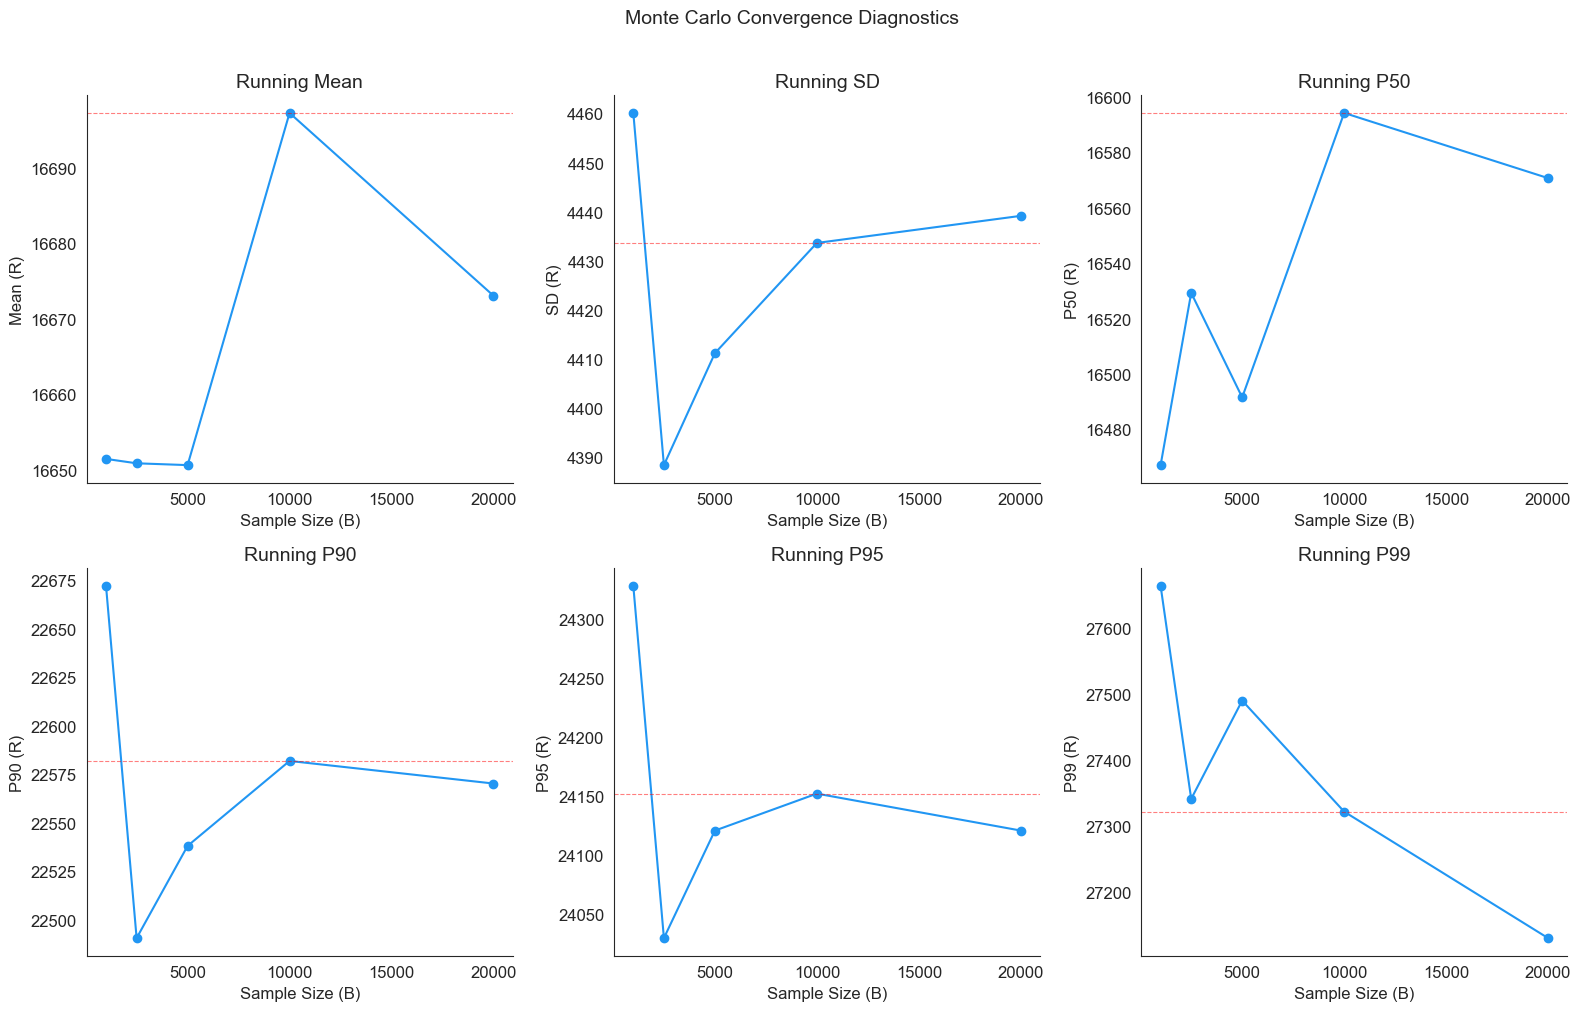

Saved: /Users/baloyithabangbonganijunior/Downloads/chapter3_figures/fig_mc_convergence.png


In [8]:
# --- Figure: MC Convergence ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

stat_cols = ['Mean', 'SD', 'P50', 'P90', 'P95', 'P99']
for idx, stat in enumerate(stat_cols):
    ax = axes[idx // 3, idx % 3]
    ax.plot(df_conv['B'], df_conv[stat], marker='o', color='#2196F3', linewidth=1.5)
    ax.set_xlabel('Sample Size (B)')
    ax.set_ylabel(f'{stat} (R)')
    ax.set_title(f'Running {stat}')
    # Add horizontal reference line at B=10000 value
    ref_val = df_conv.loc[df_conv['B'] == 10000, stat].values[0]
    ax.axhline(y=ref_val, color='red', linestyle='--', alpha=0.5, linewidth=0.8)
    sns.despine(ax=ax)

plt.suptitle('Monte Carlo Convergence Diagnostics', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_mc_convergence.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}fig_mc_convergence.png')

## 4. Simulated Input Space Summary

Descriptive statistics and distribution comparisons between the MC-simulated profiles and the training data.

In [9]:
# Descriptive stats of MC raw profiles
print('MC Simulated Profile Summary (continuous variables):')
print(df_mc[['age', 'bmi', 'children']].describe().round(2))
print()

print('MC Simulated Profile Summary (categorical variables):')
for col in ['gender', 'smoker', 'region', 'medical_history',
            'family_medical_history', 'exercise_frequency',
            'occupation', 'coverage_level']:
    vc = df_mc[col].value_counts(normalize=True).sort_index()
    print(f'\n  {col}:')
    for k, v in vc.items():
        print(f'    {k}: {v:.4f}')

MC Simulated Profile Summary (continuous variables):
            age       bmi  children
count  10000.00  10000.00  10000.00
mean      41.33     34.00      2.49
std       13.79      9.19      1.72
min       18.00     18.00      0.00
25%       29.00     25.98      1.00
50%       41.00     34.16      3.00
75%       53.00     41.83      4.00
max       65.00     50.00      5.00

MC Simulated Profile Summary (categorical variables):

  gender:
    female: 0.5015
    male: 0.4985

  smoker:
    no: 0.5066
    yes: 0.4934

  region:
    northeast: 0.2475
    northwest: 0.2490
    southeast: 0.2553
    southwest: 0.2482

  medical_history:
    Diabetes: 0.2488
    Heart disease: 0.2525
    High blood pressure: 0.2473
    None: 0.2514

  family_medical_history:
    Diabetes: 0.2493
    Heart disease: 0.2513
    High blood pressure: 0.2518
    None: 0.2476

  exercise_frequency:
    Frequently: 0.2577
    Never: 0.2503
    Occasionally: 0.2504
    Rarely: 0.2416

  occupation:
    Blue collar: 0

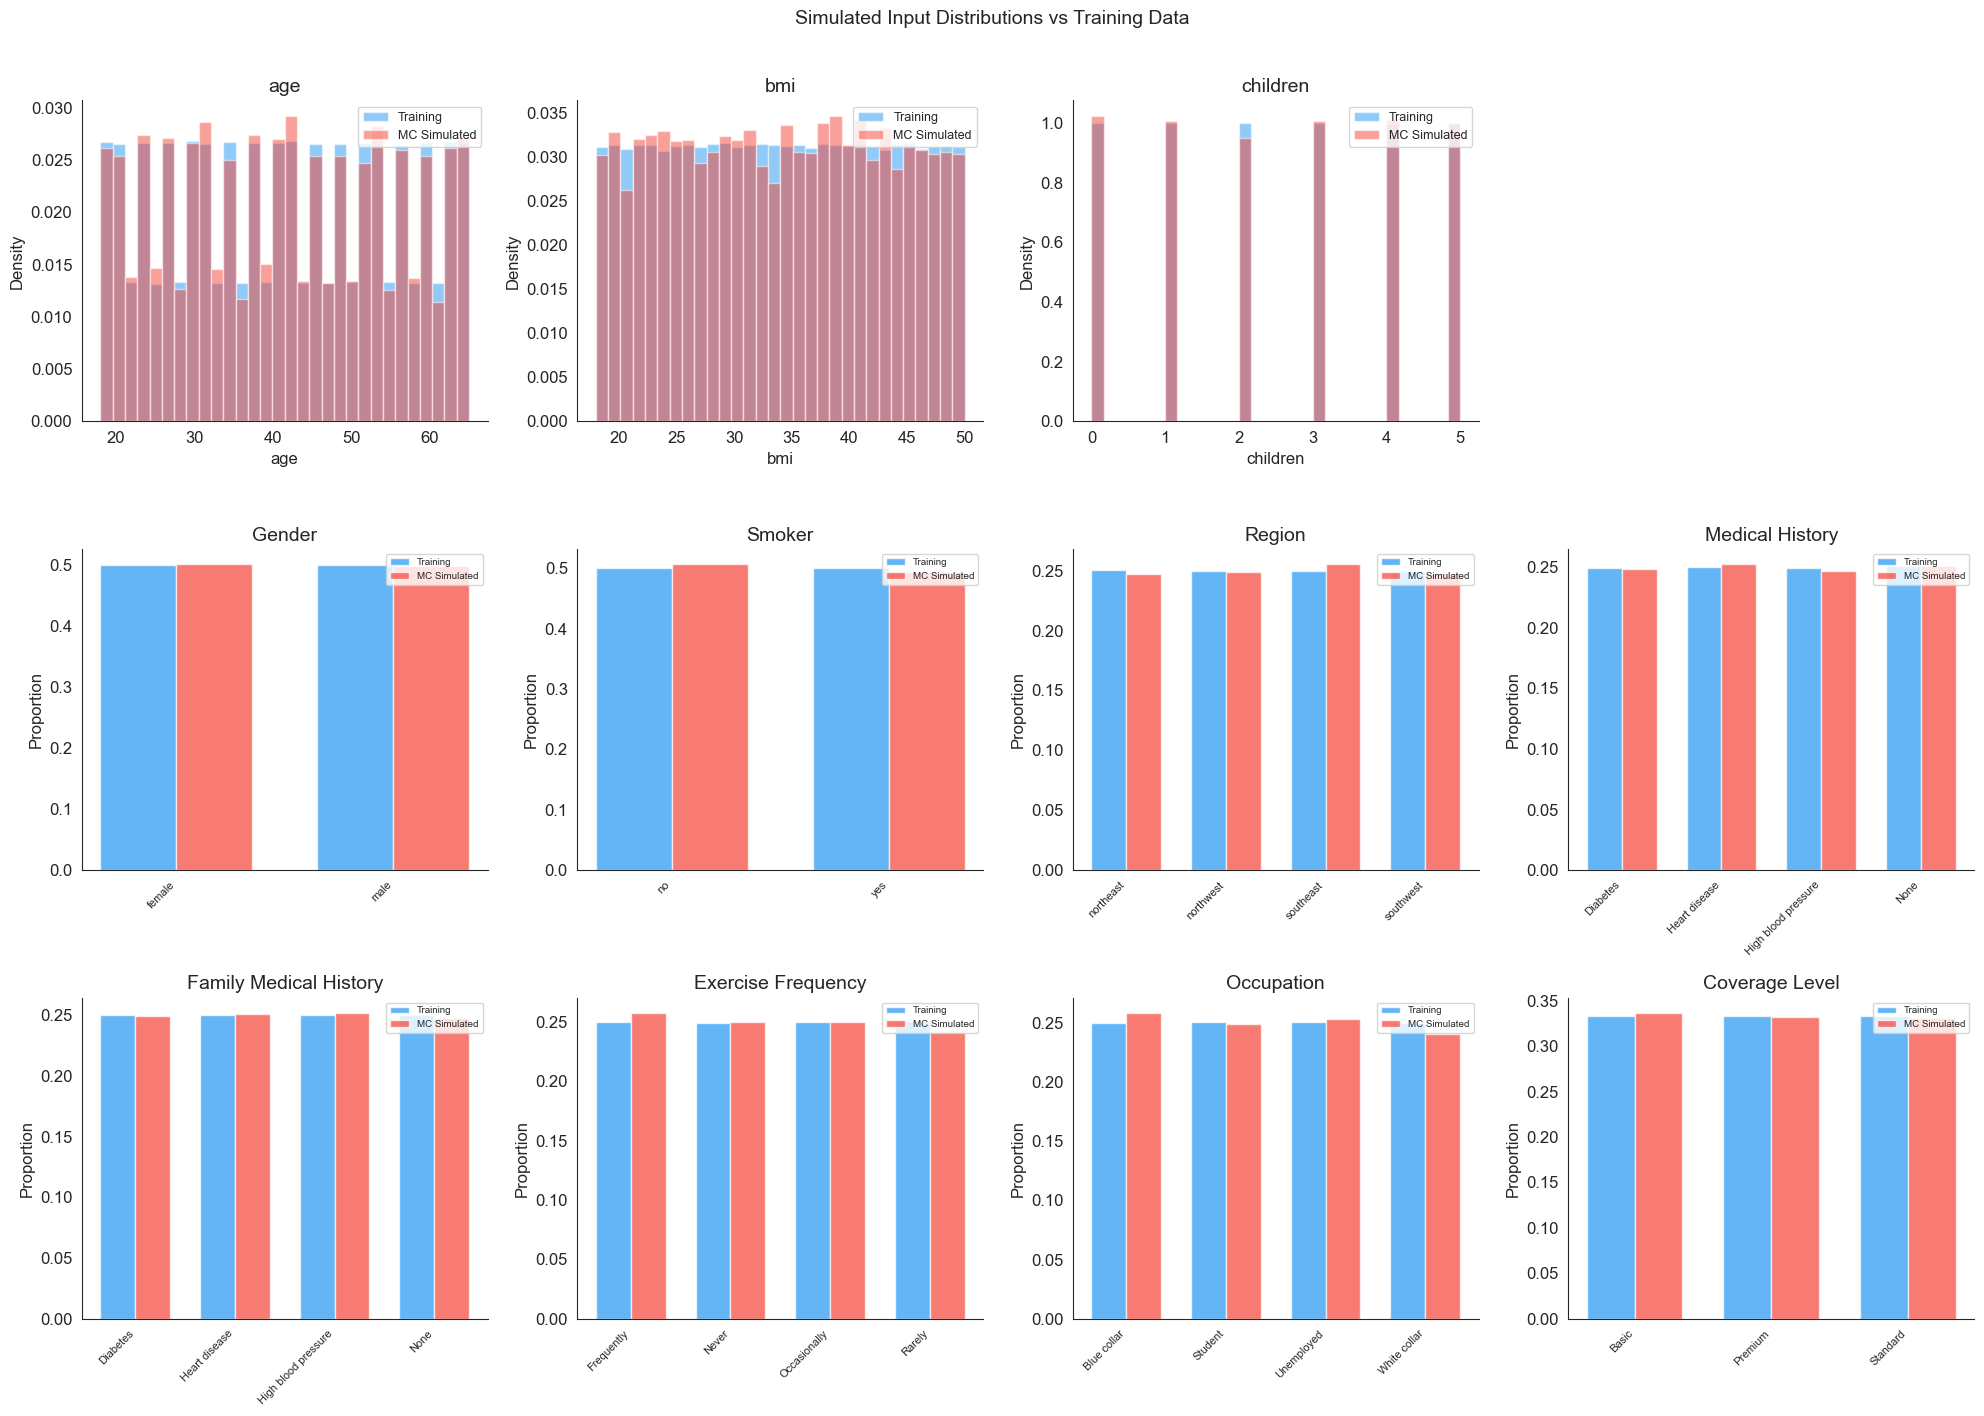

Saved: /Users/baloyithabangbonganijunior/Downloads/chapter3_figures/fig_mc_input_distributions.png


In [10]:
# --- Figure: MC Input Distributions vs Training Data ---
fig, axes = plt.subplots(3, 4, figsize=(20, 14))

# Continuous variables: overlaid histograms
cont_vars = ['age', 'bmi', 'children']
for i, var in enumerate(cont_vars):
    ax = axes[0, i]
    ax.hist(df_raw[var], bins=30, alpha=0.5, label='Training', color='#2196F3',
            density=True, edgecolor='white')
    ax.hist(df_mc[var], bins=30, alpha=0.5, label='MC Simulated', color='#F44336',
            density=True, edgecolor='white')
    ax.set_xlabel(var)
    ax.set_ylabel('Density')
    ax.set_title(var)
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

# Hide unused subplot in first row
axes[0, 3].set_visible(False)

# Categorical variables: grouped bar charts
cat_vars = ['gender', 'smoker', 'region', 'medical_history',
            'family_medical_history', 'exercise_frequency',
            'occupation', 'coverage_level']

for i, var in enumerate(cat_vars):
    row = 1 + i // 4
    col = i % 4
    ax = axes[row, col]

    train_vc = df_raw[var].value_counts(normalize=True).sort_index()
    mc_vc = df_mc[var].value_counts(normalize=True).sort_index()

    all_cats = sorted(set(train_vc.index) | set(mc_vc.index))
    x_pos = np.arange(len(all_cats))
    width = 0.35

    train_vals = [train_vc.get(c, 0) for c in all_cats]
    mc_vals = [mc_vc.get(c, 0) for c in all_cats]

    ax.bar(x_pos - width/2, train_vals, width, label='Training', color='#2196F3', alpha=0.7)
    ax.bar(x_pos + width/2, mc_vals, width, label='MC Simulated', color='#F44336', alpha=0.7)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(all_cats, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Proportion')
    ax.set_title(var.replace('_', ' ').title())
    ax.legend(fontsize=7)
    sns.despine(ax=ax)

plt.suptitle('Simulated Input Distributions vs Training Data', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_mc_input_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}fig_mc_input_distributions.png')

## 5. Base MC Predicted-Cost Distribution

Distribution of DNN-predicted insurance costs for the $B = 10\,000$ simulated profiles.

In [11]:
# Summary statistics
mc_summary = {
    'Mean': y_mc.mean(),
    'SD': y_mc.std(),
    'Skewness': float(stats.skew(y_mc)),
    'Kurtosis': float(stats.kurtosis(y_mc)),
    'Min': y_mc.min(),
    'P25': np.percentile(y_mc, 25),
    'Median': np.percentile(y_mc, 50),
    'P75': np.percentile(y_mc, 75),
    'P90': np.percentile(y_mc, 90),
    'P95': np.percentile(y_mc, 95),
    'P99': np.percentile(y_mc, 99),
    'Max': y_mc.max()
}

print('MC Predicted-Cost Distribution Summary:')
for k, v in mc_summary.items():
    print(f'  {k:<12}: {v:>12.2f}')

MC Predicted-Cost Distribution Summary:
  Mean        :     16707.47
  SD          :      4409.38
  Skewness    :         0.13
  Kurtosis    :        -0.30
  Min         :      5171.76
  P25         :     13611.58
  Median      :     16632.23
  P75         :     19694.08
  P90         :     22482.35
  P95         :     24153.90
  P99         :     27160.30
  Max         :     31466.49


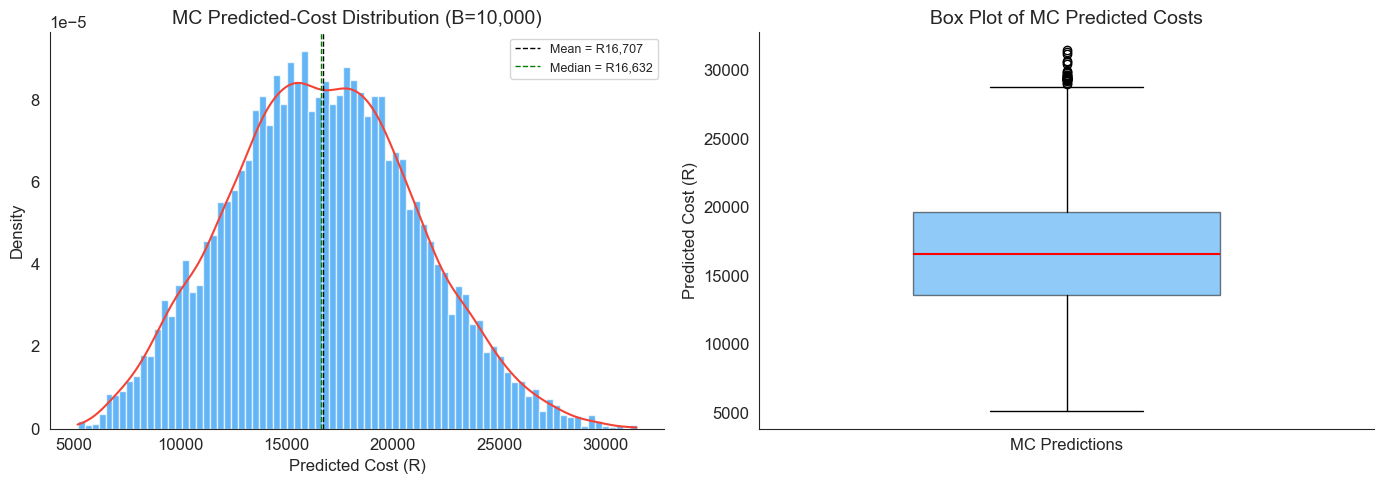

Saved: /Users/baloyithabangbonganijunior/Downloads/chapter3_figures/fig_mc_predicted_cost_distribution.png


In [12]:
# --- Figure: MC Predicted Cost Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (Left) Histogram + KDE
axes[0].hist(y_mc, bins=80, color='#2196F3', edgecolor='white', alpha=0.7, density=True)
kde_x = np.linspace(y_mc.min(), y_mc.max(), 500)
kde = stats.gaussian_kde(y_mc)
axes[0].plot(kde_x, kde(kde_x), color='#F44336', linewidth=1.5)
axes[0].axvline(y_mc.mean(), color='black', linestyle='--', linewidth=1,
                label=f'Mean = R{y_mc.mean():,.0f}')
axes[0].axvline(np.median(y_mc), color='green', linestyle='--', linewidth=1,
                label=f'Median = R{np.median(y_mc):,.0f}')
axes[0].set_xlabel('Predicted Cost (R)')
axes[0].set_ylabel('Density')
axes[0].set_title('MC Predicted-Cost Distribution (B=10,000)')
axes[0].legend(fontsize=9)
sns.despine(ax=axes[0])

# (Right) Box plot
axes[1].boxplot(y_mc, vert=True, widths=0.5,
                patch_artist=True,
                boxprops=dict(facecolor='#2196F3', alpha=0.5),
                medianprops=dict(color='red', linewidth=1.5))
axes[1].set_ylabel('Predicted Cost (R)')
axes[1].set_title('Box Plot of MC Predicted Costs')
axes[1].set_xticklabels(['MC Predictions'])
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_mc_predicted_cost_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}fig_mc_predicted_cost_distribution.png')

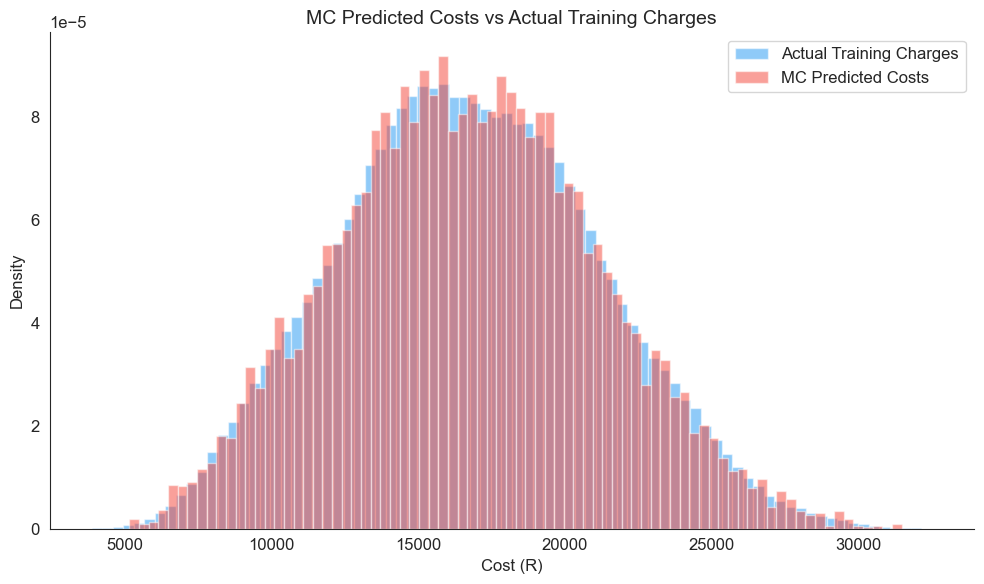

Saved: /Users/baloyithabangbonganijunior/Downloads/chapter3_figures/fig_mc_predicted_vs_actual.png

Distribution Comparison:
Statistic      Actual Train   MC Predicted
----------------------------------------
Mean              16,739.52      16,707.47
SD                 4,415.99       4,409.38
Median            16,625.97      16,632.23
P90               22,590.13      22,482.35
P95               24,235.09      24,153.90
P99               26,997.93      27,160.30


In [13]:
# --- Figure: MC Predicted vs Actual Training Charges ---
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(y_train_raw, bins=80, alpha=0.5, label='Actual Training Charges',
        color='#2196F3', density=True, edgecolor='white')
ax.hist(y_mc, bins=80, alpha=0.5, label='MC Predicted Costs',
        color='#F44336', density=True, edgecolor='white')
ax.set_xlabel('Cost (R)')
ax.set_ylabel('Density')
ax.set_title('MC Predicted Costs vs Actual Training Charges')
ax.legend()
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_mc_predicted_vs_actual.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}fig_mc_predicted_vs_actual.png')

# Comparison table
print('\nDistribution Comparison:')
print(f'{"Statistic":<12} {"Actual Train":>14} {"MC Predicted":>14}')
print('-' * 40)
for stat_name, stat_fn in [('Mean', np.mean), ('SD', np.std),
                            ('Median', np.median)]:
    print(f'{stat_name:<12} {stat_fn(y_train_raw):>14,.2f} {stat_fn(y_mc):>14,.2f}')
for q in [90, 95, 99]:
    print(f'{"P" + str(q):<12} {np.percentile(y_train_raw, q):>14,.2f} {np.percentile(y_mc, q):>14,.2f}')

## 6. Residual-Augmented MC Sensitivity (Algorithm 3.2)

Incorporate model uncertainty by augmenting base predictions with centred training residuals:
$$Y_{\text{res}} = \hat{Y} + \epsilon, \quad \epsilon \sim F_{\hat{\epsilon}}$$
where $\hat{\epsilon}_i = Y_i - \hat{Y}_i$ are the centred training residuals.

Fixed perturbation bands:
$$Y^{\pm} = \hat{Y} \pm 0.5 \cdot \sigma_{\epsilon}$$

In [14]:
# --- Compute training residuals ---
y_train_pred = score_dnn(X_train_raw, standardise=True, denormalise=True)
residuals_train = y_train_raw - y_train_pred

# Centre the residuals
residuals_centred = residuals_train - residuals_train.mean()

sigma_e = residuals_centred.std()
print(f'Training residuals:')
print(f'  Mean (raw)    : {residuals_train.mean():.4f}')
print(f'  Mean (centred): {residuals_centred.mean():.6f}')
print(f'  SD (sigma_e)  : {sigma_e:.2f}')
print(f'  Skewness      : {stats.skew(residuals_centred):.4f}')
print(f'  Kurtosis      : {stats.kurtosis(residuals_centred):.4f}')

Training residuals:
  Mean (raw)    : 1.2527
  Mean (centred): 0.000007
  SD (sigma_e)  : 289.42
  Skewness      : -0.0001
  Kurtosis      : -1.1638


In [15]:
# --- Residual-augmented predictions ---
rng_res = np.random.default_rng(SEED + 1)
eps_sample = rng_res.choice(residuals_centred, size=B, replace=True)
y_mc_augmented = y_mc + eps_sample

# Fixed perturbation bands
y_mc_upper = y_mc + 0.5 * sigma_e
y_mc_lower = y_mc - 0.5 * sigma_e

print(f'\nResidual-Augmented Distribution:')
print(f'  Mean : R{y_mc_augmented.mean():,.2f} (base: R{y_mc.mean():,.2f})')
print(f'  SD   : R{y_mc_augmented.std():,.2f} (base: R{y_mc.std():,.2f})')
print(f'  P95  : R{np.percentile(y_mc_augmented, 95):,.2f} (base: R{np.percentile(y_mc, 95):,.2f})')


Residual-Augmented Distribution:
  Mean : R16,708.17 (base: R16,707.47)
  SD   : R4,420.49 (base: R4,409.38)
  P95  : R24,199.44 (base: R24,153.90)


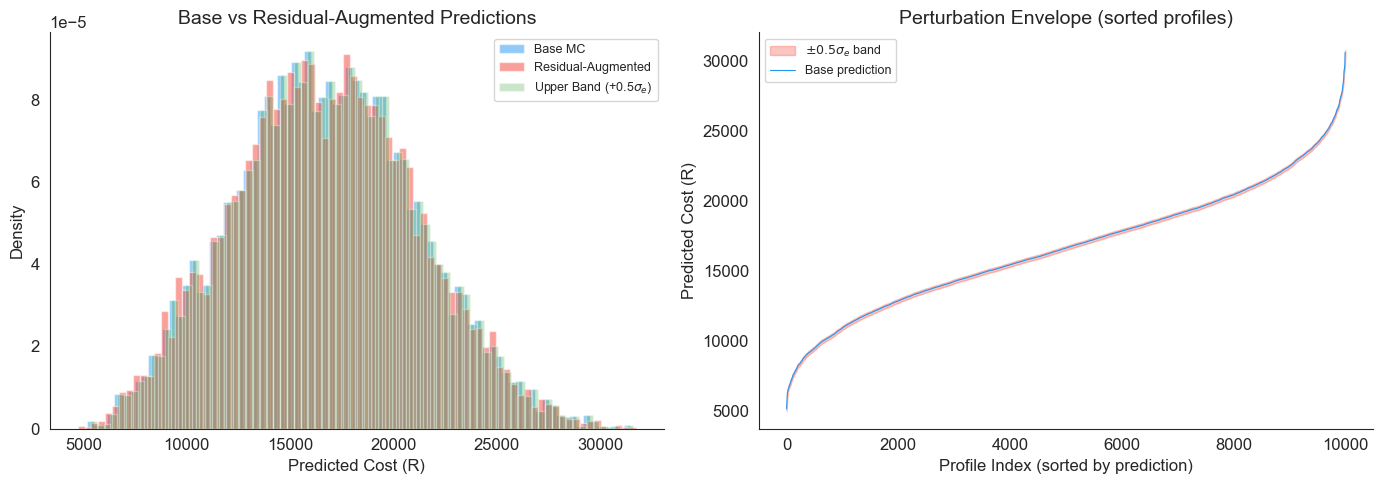

Saved: /Users/baloyithabangbonganijunior/Downloads/chapter3_figures/fig_mc_residual_augmented.png


In [16]:
# --- Figure: Residual-Augmented MC ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (Left) Base vs Augmented vs Perturbation Band
axes[0].hist(y_mc, bins=80, alpha=0.5, label='Base MC', color='#2196F3',
             density=True, edgecolor='white')
axes[0].hist(y_mc_augmented, bins=80, alpha=0.5, label='Residual-Augmented',
             color='#F44336', density=True, edgecolor='white')
axes[0].hist(y_mc_upper, bins=80, alpha=0.3, label='Upper Band (+0.5$\\sigma_e$)',
             color='#4CAF50', density=True, edgecolor='white')
axes[0].set_xlabel('Predicted Cost (R)')
axes[0].set_ylabel('Density')
axes[0].set_title('Base vs Residual-Augmented Predictions')
axes[0].legend(fontsize=9)
sns.despine(ax=axes[0])

# (Right) Sorted predictions with perturbation envelope
sort_idx = np.argsort(y_mc)
n_plot = min(2000, B)
step = max(1, B // n_plot)
plot_idx = np.arange(0, B, step)

axes[1].fill_between(plot_idx, y_mc_lower[sort_idx][plot_idx],
                     y_mc_upper[sort_idx][plot_idx],
                     alpha=0.3, color='#F44336', label='$\\pm 0.5\\sigma_e$ band')
axes[1].plot(plot_idx, y_mc[sort_idx][plot_idx], color='#2196F3',
             linewidth=0.8, label='Base prediction')
axes[1].set_xlabel('Profile Index (sorted by prediction)')
axes[1].set_ylabel('Predicted Cost (R)')
axes[1].set_title('Perturbation Envelope (sorted profiles)')
axes[1].legend(fontsize=9)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_mc_residual_augmented.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}fig_mc_residual_augmented.png')

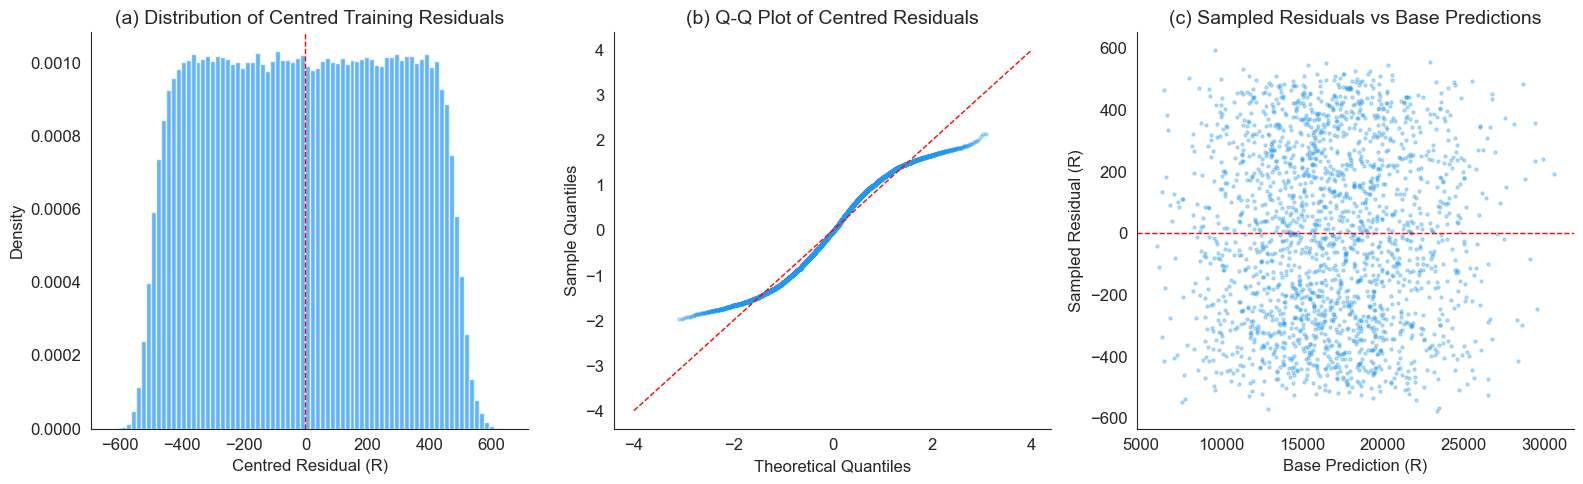

Saved: /Users/baloyithabangbonganijunior/Downloads/chapter3_figures/fig_mc_residual_diagnostics.png


In [17]:
# --- Figure: Residual Diagnostics ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) Histogram of centred training residuals
axes[0].hist(residuals_centred, bins=80, color='#2196F3', edgecolor='white',
             alpha=0.7, density=True)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Centred Residual (R)')
axes[0].set_ylabel('Density')
axes[0].set_title('(a) Distribution of Centred Training Residuals')
sns.despine(ax=axes[0])

# (b) QQ plot of centred residuals
std_res = (residuals_centred - residuals_centred.mean()) / residuals_centred.std()
qq_sample = rng.choice(std_res, min(5000, len(std_res)), replace=False)
qq_sample.sort()
theoretical = stats.norm.ppf(np.linspace(0.001, 0.999, len(qq_sample)))
axes[1].scatter(theoretical, qq_sample, alpha=0.3, s=5, color='#2196F3')
axes[1].plot([-4, 4], [-4, 4], 'r--', linewidth=1)
axes[1].set_xlabel('Theoretical Quantiles')
axes[1].set_ylabel('Sample Quantiles')
axes[1].set_title('(b) Q-Q Plot of Centred Residuals')
sns.despine(ax=axes[1])

# (c) Sampled epsilon vs base predictions
axes[2].scatter(y_mc[:2000], eps_sample[:2000], alpha=0.3, s=5, color='#2196F3')
axes[2].axhline(0, color='red', linestyle='--', linewidth=1)
axes[2].set_xlabel('Base Prediction (R)')
axes[2].set_ylabel('Sampled Residual (R)')
axes[2].set_title('(c) Sampled Residuals vs Base Predictions')
sns.despine(ax=axes[2])

plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_mc_residual_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}fig_mc_residual_diagnostics.png')

## 7. SHAP Global Attribution

Use SHAP GradientExplainer with a background sample of ~200 training rows to compute Shapley values for all 10,000 MC-simulated profiles on the 22 encoded features.  
Shapley values are then aggregated to the 11 raw input variables using the dummy-group mapping.

In [18]:
# --- Prepare SHAP background and foreground data ---
# SHAP GradientExplainer runs significantly faster on CPU than MPS,
# so we use a CPU copy of the model for all SHAP computations.
model_cpu = copy.deepcopy(model).cpu()
model_cpu.eval()

# Background: 200 randomly sampled standardised training rows
bg_idx = rng.choice(len(X_train_std), 200, replace=False)
X_bg = torch.tensor(X_train_std[bg_idx], dtype=torch.float32)

# Foreground: all MC profiles (standardised)
X_mc_std = ((X_mc_encoded - X_mean) / X_std).astype(np.float32)
X_fg = torch.tensor(X_mc_std, dtype=torch.float32)

print(f'SHAP model device: {next(model_cpu.parameters()).device}')
print(f'SHAP background  : {X_bg.shape}')
print(f'SHAP foreground  : {X_fg.shape}')

SHAP model device: cpu
SHAP background  : torch.Size([200, 22])
SHAP foreground  : torch.Size([10000, 22])


In [19]:
# --- Compute SHAP values ---
explainer = shap.GradientExplainer(model_cpu, X_bg)

# Process in batches to manage memory
BATCH_SHAP = 2000
shap_values_list = []
n_batches = (B + BATCH_SHAP - 1) // BATCH_SHAP

for i in range(n_batches):
    start = i * BATCH_SHAP
    end = min((i + 1) * BATCH_SHAP, B)
    sv = explainer.shap_values(X_fg[start:end])
    if isinstance(sv, list):
        sv = sv[0]
    if isinstance(sv, torch.Tensor):
        sv = sv.cpu().numpy()
    # GradientExplainer returns shape (n, 22, 1) for single-output models
    if sv.ndim == 3 and sv.shape[-1] == 1:
        sv = sv.squeeze(-1)
    shap_values_list.append(sv)
    print(f'  Batch {i+1}/{n_batches} complete ({end - start} profiles)')

shap_values_22 = np.concatenate(shap_values_list, axis=0)
print(f'\nSHAP values shape: {shap_values_22.shape}')

  Batch 1/5 complete (2000 profiles)


  Batch 2/5 complete (2000 profiles)


  Batch 3/5 complete (2000 profiles)


  Batch 4/5 complete (2000 profiles)


  Batch 5/5 complete (2000 profiles)

SHAP values shape: (10000, 22)


In [20]:
# --- SHAP efficiency check ---
# phi_0 + sum(phi_j) should approximately equal the model prediction (normalised)
# phi_0 is the expected model output on the background
with torch.no_grad():
    phi_0 = model_cpu(X_bg).mean().item()

with torch.no_grad():
    y_mc_norm = model_cpu(X_fg).numpy().flatten()

reconstructed = phi_0 + shap_values_22.sum(axis=1)
efficiency_error = np.abs(reconstructed - y_mc_norm)

print('SHAP Efficiency Check (normalised scale):')
print(f'  phi_0 (base value)     : {phi_0:.6f}')
print(f'  Mean |reconstruction error|: {efficiency_error.mean():.6f}')
print(f'  Max  |reconstruction error|: {efficiency_error.max():.6f}')
print(f'  Mean predicted (norm)  : {y_mc_norm.mean():.6f}')
print(f'  Efficiency holds: {(efficiency_error.max() < 0.5)}')

SHAP Efficiency Check (normalised scale):
  phi_0 (base value)     : -0.044163
  Mean |reconstruction error|: 0.076263
  Max  |reconstruction error|: 0.377866
  Mean predicted (norm)  : -0.007257
  Efficiency holds: True


In [21]:
# --- Aggregate SHAP values from 22 encoded to 11 raw variables ---
# Dummy-group mapping: each raw variable maps to one or more encoded columns
raw_to_encoded = {
    'age': [0],
    'gender': [1],
    'bmi': [2],
    'children': [3],
    'smoker': [4],
    'region': [5, 6, 7],           # southwest, northwest, southeast
    'medical_history': [8, 9, 10], # Heart_disease, High_blood_pressure, Diabetes
    'family_medical_history': [11, 12, 13],
    'exercise_frequency': [14, 15, 16],  # Occasionally, Frequently, Never
    'occupation': [17, 18, 19],    # Student, Blue_collar, White_collar
    'coverage_level': [20, 21]     # Standard, Premium
}

RAW_VARS = list(raw_to_encoded.keys())

# Aggregate: sum the SHAP values of dummy columns for each raw variable
shap_values_11 = np.zeros((B, 11), dtype=np.float32)
for j, (var_name, col_indices) in enumerate(raw_to_encoded.items()):
    shap_values_11[:, j] = shap_values_22[:, col_indices].sum(axis=1)

print(f'Aggregated SHAP values shape: {shap_values_11.shape}')
print(f'Raw variables: {RAW_VARS}')

Aggregated SHAP values shape: (10000, 11)
Raw variables: ['age', 'gender', 'bmi', 'children', 'smoker', 'region', 'medical_history', 'family_medical_history', 'exercise_frequency', 'occupation', 'coverage_level']


In [22]:
# --- Global SHAP importance (mean signed and mean absolute) ---
mean_signed = shap_values_11.mean(axis=0)
mean_abs = np.abs(shap_values_11).mean(axis=0)

df_global_shap = pd.DataFrame({
    'Variable': RAW_VARS,
    'Mean Signed SHAP': mean_signed,
    'Mean |SHAP|': mean_abs
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

print('Global SHAP Importance (11 raw variables, normalised scale):')
print(df_global_shap.to_string(index=False, float_format='%.6f'))

Global SHAP Importance (11 raw variables, normalised scale):
              Variable  Mean Signed SHAP  Mean |SHAP|
                smoker          0.022117     0.577085
        coverage_level          0.020142     0.401242
       medical_history         -0.030392     0.368215
family_medical_history          0.006943     0.351858
            occupation          0.011241     0.170456
    exercise_frequency          0.008511     0.150672
                gender         -0.002224     0.121762
                   bmi         -0.007392     0.099429
              children          0.008213     0.067585
                   age         -0.001955     0.058175
                region          0.001643     0.055980


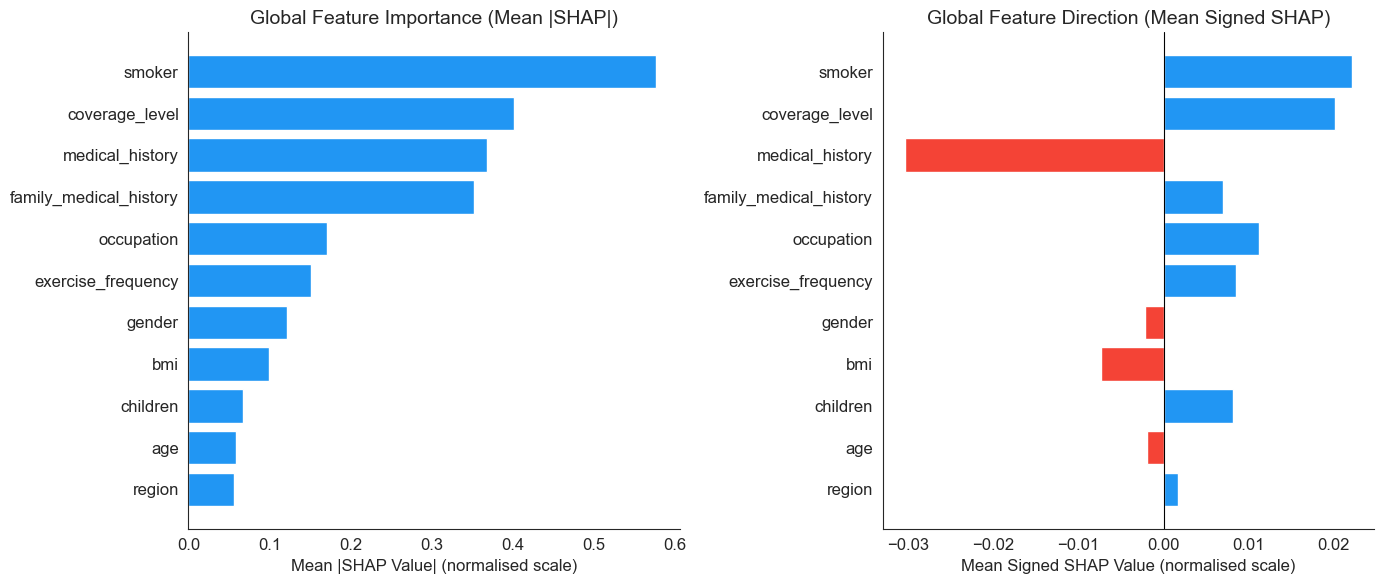

Saved: /Users/baloyithabangbonganijunior/Downloads/chapter3_figures/fig_shap_global_importance.png


In [23]:
# --- Figure: Global SHAP Importance Bar Chart ---
df_plot = df_global_shap.sort_values('Mean |SHAP|', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# (Left) Mean |SHAP|
axes[0].barh(df_plot['Variable'], df_plot['Mean |SHAP|'],
             color='#2196F3', edgecolor='white')
axes[0].set_xlabel('Mean |SHAP Value| (normalised scale)')
axes[0].set_title('Global Feature Importance (Mean |SHAP|)')
sns.despine(ax=axes[0])

# (Right) Mean Signed SHAP
colours = ['#2196F3' if v >= 0 else '#F44336' for v in df_plot['Mean Signed SHAP']]
axes[1].barh(df_plot['Variable'], df_plot['Mean Signed SHAP'],
             color=colours, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Mean Signed SHAP Value (normalised scale)')
axes[1].set_title('Global Feature Direction (Mean Signed SHAP)')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_shap_global_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}fig_shap_global_importance.png')

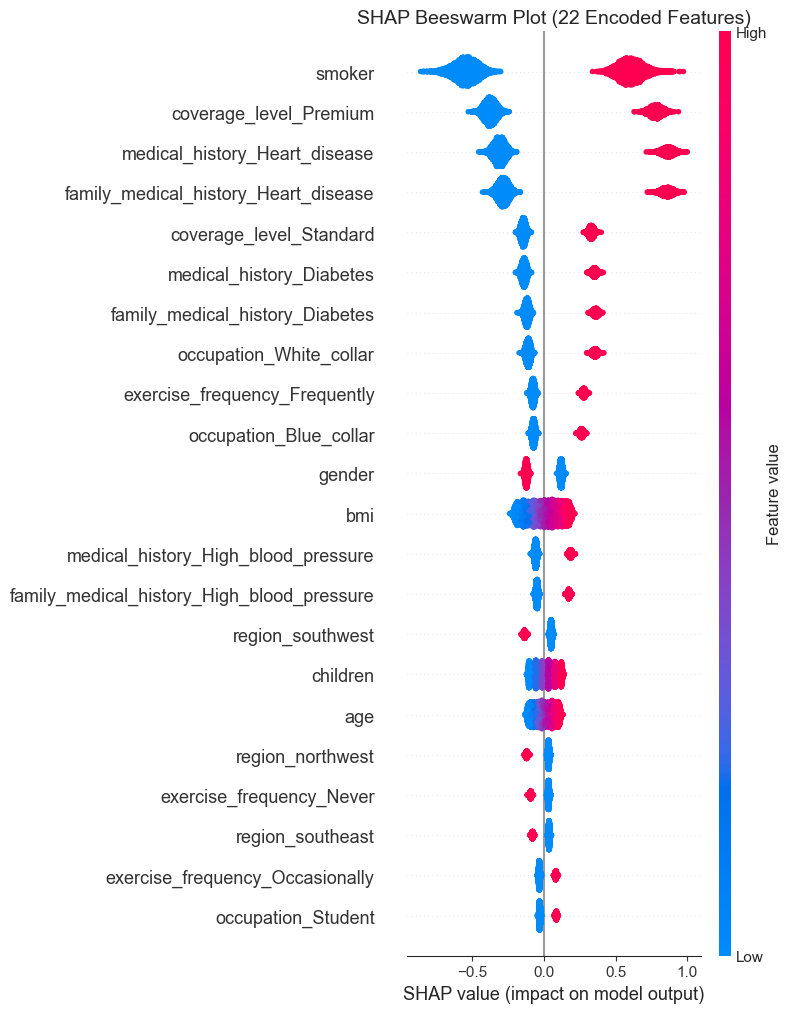

Saved: /Users/baloyithabangbonganijunior/Downloads/chapter3_figures/fig_shap_beeswarm.png


In [24]:
# --- Figure: SHAP Beeswarm Plot (22 encoded features) ---
# Use SHAP's built-in beeswarm on the encoded features
shap_explanation = shap.Explanation(
    values=shap_values_22,
    base_values=np.full(B, phi_0),
    data=X_mc_std,
    feature_names=FEATURES
)

fig, ax = plt.subplots(figsize=(10, 10))
shap.plots.beeswarm(shap_explanation, max_display=22, show=False)
plt.title('SHAP Beeswarm Plot (22 Encoded Features)')
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_shap_beeswarm.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}fig_shap_beeswarm.png')

## 8. High-Cost Region Analysis

Define high-cost thresholds at $\tau \in \{0.90, 0.95, 0.99\}$ and identify the corresponding high-cost sets $H_{\tau}$.

In [25]:
# --- High-cost thresholds ---
thresholds = {'tau_90': 0.90, 'tau_95': 0.95, 'tau_99': 0.99}
u_vals = {}
h_sets = {}

for name, tau in thresholds.items():
    u = np.percentile(y_mc, tau * 100)
    mask = y_mc >= u
    u_vals[name] = u
    h_sets[name] = mask

print('High-Cost Thresholds and Set Sizes:')
print(f'{"Threshold":<12} {"u (R)":>12} {"n(H)":>8} {"Proportion":>12}')
print('-' * 44)
for name, tau in thresholds.items():
    n_h = h_sets[name].sum()
    print(f'{name:<12} {u_vals[name]:>12,.2f} {n_h:>8d} {n_h/B:>12.4f}')

High-Cost Thresholds and Set Sizes:
Threshold           u (R)     n(H)   Proportion
--------------------------------------------
tau_90          22,482.35     1000       0.1000
tau_95          24,153.90      500       0.0500
tau_99          27,160.30      100       0.0100


In [26]:
# --- Profile high-cost subsets ---
print('High-Cost Subset Characteristics (raw profiles):')
print('=' * 70)

for name in ['tau_90', 'tau_95', 'tau_99']:
    mask = h_sets[name]
    df_hc = df_mc[mask]
    print(f'\n--- {name} (n={mask.sum()}, threshold=R{u_vals[name]:,.2f}) ---')

    # Continuous variables
    print(f'  age     : mean={df_hc["age"].mean():.1f}, median={df_hc["age"].median():.0f}')
    print(f'  bmi     : mean={df_hc["bmi"].mean():.1f}, median={df_hc["bmi"].median():.1f}')
    print(f'  children: mean={df_hc["children"].mean():.1f}, median={df_hc["children"].median():.0f}')

    # Key categorical proportions
    print(f'  smoker=yes : {(df_hc["smoker"]=="yes").mean():.2%}')
    print(f'  male       : {(df_hc["gender"]=="male").mean():.2%}')
    print(f'  Premium    : {(df_hc["coverage_level"]=="Premium").mean():.2%}')

High-Cost Subset Characteristics (raw profiles):

--- tau_90 (n=1000, threshold=R22,482.35) ---
  age     : mean=42.4, median=43
  bmi     : mean=35.3, median=36.5
  children: mean=2.7, median=3
  smoker=yes : 92.90%
  male       : 40.50%
  Premium    : 72.40%

--- tau_95 (n=500, threshold=R24,153.90) ---
  age     : mean=43.0, median=44
  bmi     : mean=36.1, median=37.5
  children: mean=2.8, median=3
  smoker=yes : 96.20%
  male       : 38.00%
  Premium    : 80.20%

--- tau_99 (n=100, threshold=R27,160.30) ---
  age     : mean=41.8, median=44
  bmi     : mean=36.9, median=38.2
  children: mean=2.8, median=3
  smoker=yes : 99.00%
  male       : 36.00%
  Premium    : 93.00%


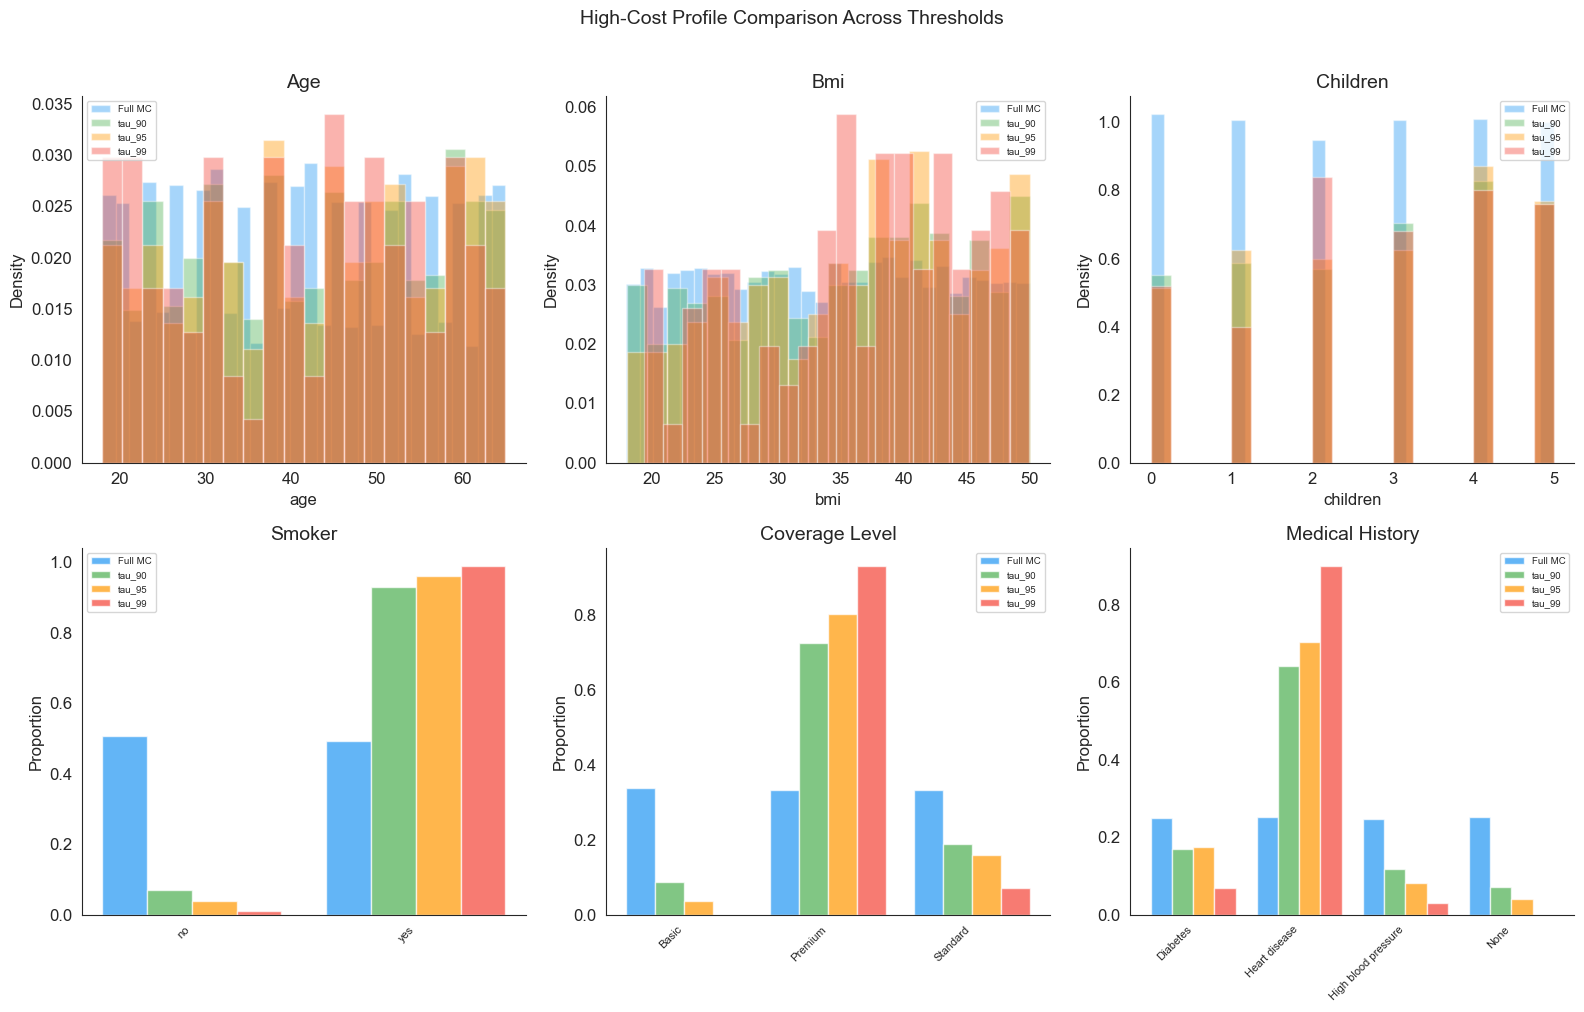

Saved: /Users/baloyithabangbonganijunior/Downloads/chapter3_figures/fig_highcost_profile_comparison.png


In [27]:
# --- Figure: High-Cost Profile Comparison ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Compare distributions for key variables across thresholds
compare_vars = [
    ('age', 'continuous'),
    ('bmi', 'continuous'),
    ('children', 'continuous'),
    ('smoker', 'categorical'),
    ('coverage_level', 'categorical'),
    ('medical_history', 'categorical')
]

colours_thresh = {'Full MC': '#2196F3', 'tau_90': '#4CAF50',
                  'tau_95': '#FF9800', 'tau_99': '#F44336'}

for idx, (var, vtype) in enumerate(compare_vars):
    ax = axes[idx // 3, idx % 3]

    if vtype == 'continuous':
        ax.hist(df_mc[var], bins=30, alpha=0.4, label='Full MC',
                color=colours_thresh['Full MC'], density=True, edgecolor='white')
        for name in ['tau_90', 'tau_95', 'tau_99']:
            mask = h_sets[name]
            if mask.sum() > 5:
                ax.hist(df_mc.loc[mask, var], bins=20, alpha=0.4,
                        label=name, color=colours_thresh[name],
                        density=True, edgecolor='white')
        ax.set_xlabel(var)
        ax.set_ylabel('Density')
    else:
        cats = sorted(df_mc[var].unique())
        x_pos = np.arange(len(cats))
        width = 0.2
        offsets = {'Full MC': -1.5, 'tau_90': -0.5, 'tau_95': 0.5, 'tau_99': 1.5}

        for label, offset in offsets.items():
            if label == 'Full MC':
                vals = [((df_mc[var] == c).mean()) for c in cats]
            else:
                mask = h_sets[label]
                if mask.sum() > 0:
                    vals = [((df_mc.loc[mask, var] == c).mean()) for c in cats]
                else:
                    vals = [0] * len(cats)
            ax.bar(x_pos + offset * width, vals, width,
                   label=label, color=colours_thresh[label], alpha=0.7)

        ax.set_xticks(x_pos)
        ax.set_xticklabels(cats, rotation=45, ha='right', fontsize=8)
        ax.set_ylabel('Proportion')

    ax.set_title(var.replace('_', ' ').title())
    ax.legend(fontsize=7)
    sns.despine(ax=ax)

plt.suptitle('High-Cost Profile Comparison Across Thresholds', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_highcost_profile_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}fig_highcost_profile_comparison.png')

## 9. Conditional Shapley Summaries

Compute conditional mean signed and mean absolute SHAP values for profiles in $H_{\tau}$ at $\tau \in \{0.90, 0.95, 0.99\}$.  
Compare global vs conditional importance to identify which features drive high-cost predictions.

In [28]:
# --- Conditional SHAP summaries ---
conditional_results = {}

for name in ['tau_90', 'tau_95', 'tau_99']:
    mask = h_sets[name]
    sv_cond = shap_values_11[mask]

    cond_mean_signed = sv_cond.mean(axis=0)
    cond_mean_abs = np.abs(sv_cond).mean(axis=0)

    df_cond = pd.DataFrame({
        'Variable': RAW_VARS,
        'Cond Mean Signed': cond_mean_signed,
        'Cond Mean |SHAP|': cond_mean_abs
    }).sort_values('Cond Mean |SHAP|', ascending=False).reset_index(drop=True)

    conditional_results[name] = df_cond

    print(f'\nConditional SHAP ({name}, n={mask.sum()}):')
    print(df_cond.to_string(index=False, float_format='%.6f'))


Conditional SHAP (tau_90, n=1000):
              Variable  Cond Mean Signed  Cond Mean |SHAP|
                smoker          0.509992          0.596122
        coverage_level          0.406407          0.515254
       medical_history          0.352643          0.502082
family_medical_history          0.377915          0.497911
            occupation          0.067879          0.182541
    exercise_frequency          0.054922          0.163728
                gender          0.020001          0.122035
                   bmi          0.007848          0.099460
              children          0.018316          0.067983
                region          0.011078          0.061690
                   age          0.003623          0.057558

Conditional SHAP (tau_95, n=500):
              Variable  Cond Mean Signed  Cond Mean |SHAP|
                smoker          0.534664          0.583761
        coverage_level          0.483113          0.537199
family_medical_history          0.432521    

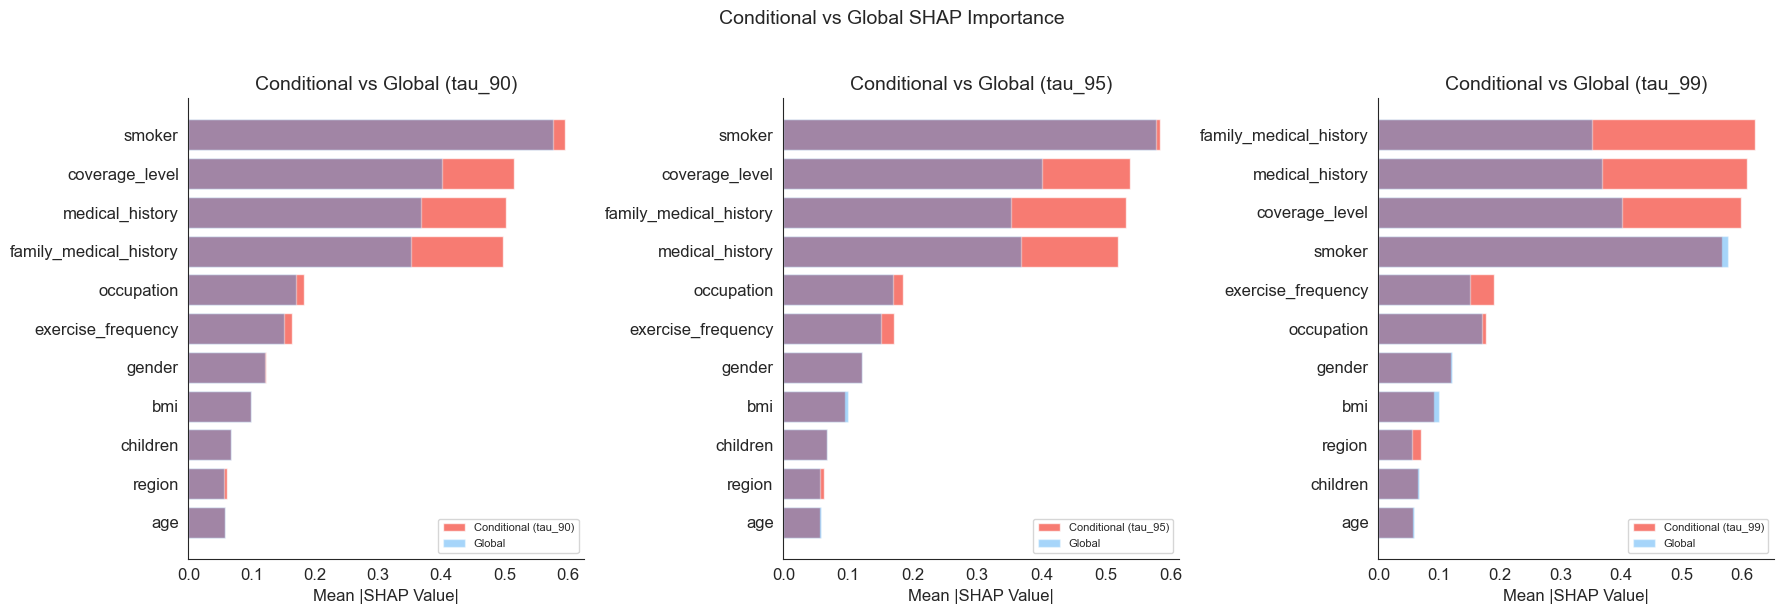

Saved: /Users/baloyithabangbonganijunior/Downloads/chapter3_figures/fig_shap_conditional_importance.png


In [29]:
# --- Figure: Conditional SHAP Importance ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, name in enumerate(['tau_90', 'tau_95', 'tau_99']):
    df_cond = conditional_results[name].sort_values('Cond Mean |SHAP|', ascending=True)
    ax = axes[idx]
    ax.barh(df_cond['Variable'], df_cond['Cond Mean |SHAP|'],
            color='#F44336', edgecolor='white', alpha=0.7,
            label=f'Conditional ({name})')

    # Overlay global importance for comparison
    global_vals = [df_global_shap.loc[df_global_shap['Variable'] == v, 'Mean |SHAP|'].values[0]
                   for v in df_cond['Variable']]
    ax.barh(df_cond['Variable'], global_vals,
            color='#2196F3', edgecolor='white', alpha=0.4,
            label='Global')

    ax.set_xlabel('Mean |SHAP Value|')
    ax.set_title(f'Conditional vs Global ({name})')
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

plt.suptitle('Conditional vs Global SHAP Importance', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_shap_conditional_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}fig_shap_conditional_importance.png')

Representative high-cost profile (index 955):
  Predicted cost: R24,153.85
  P95 threshold : R24,153.90
  Raw profile   :
    age: 47
    gender: female
    bmi: 38.514059619686485
    children: 4
    smoker: yes
    region: northeast
    medical_history: High blood pressure
    family_medical_history: Heart disease
    exercise_frequency: Frequently
    occupation: Blue collar
    coverage_level: Standard


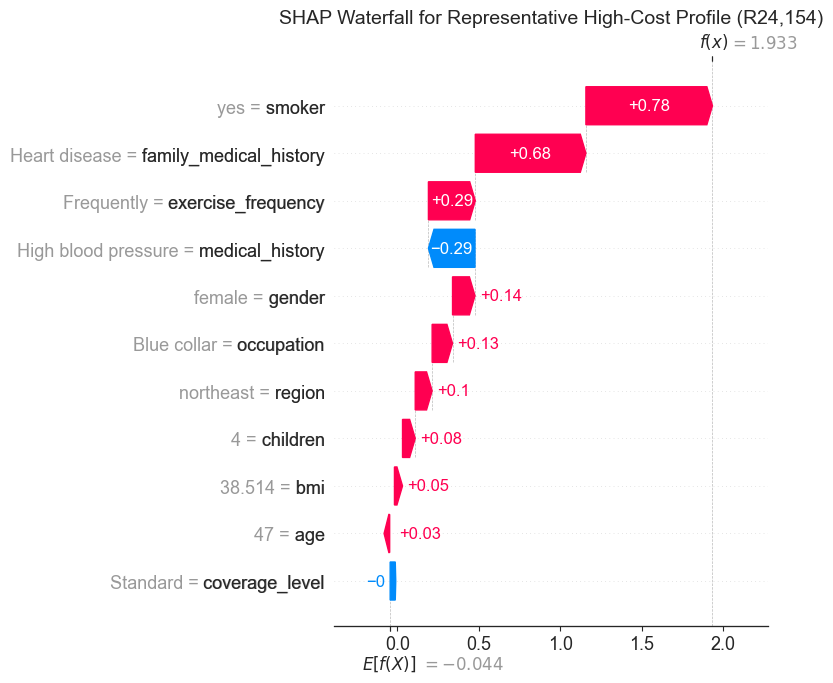

Saved: /Users/baloyithabangbonganijunior/Downloads/chapter3_figures/fig_shap_highcost_waterfall.png


In [30]:
# --- Figure: Waterfall for Representative High-Cost Profile ---
# Select the profile closest to the P95 threshold
target_cost = u_vals['tau_95']
diffs = np.abs(y_mc - target_cost)
rep_idx = np.argmin(diffs)

print(f'Representative high-cost profile (index {rep_idx}):')
print(f'  Predicted cost: R{y_mc[rep_idx]:,.2f}')
print(f'  P95 threshold : R{target_cost:,.2f}')
print(f'  Raw profile   :')
for col in df_mc.columns:
    print(f'    {col}: {df_mc.iloc[rep_idx][col]}')

# Create waterfall using the 11 aggregated variables
rep_shap = shap_values_11[rep_idx]
rep_explanation = shap.Explanation(
    values=rep_shap,
    base_values=phi_0,
    data=np.array([df_mc.iloc[rep_idx][v] for v in RAW_VARS], dtype=object),
    feature_names=RAW_VARS
)

fig, ax = plt.subplots(figsize=(10, 8))
shap.plots.waterfall(rep_explanation, max_display=11, show=False)
plt.title(f'SHAP Waterfall for Representative High-Cost Profile (R{y_mc[rep_idx]:,.0f})')
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_shap_highcost_waterfall.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}fig_shap_highcost_waterfall.png')

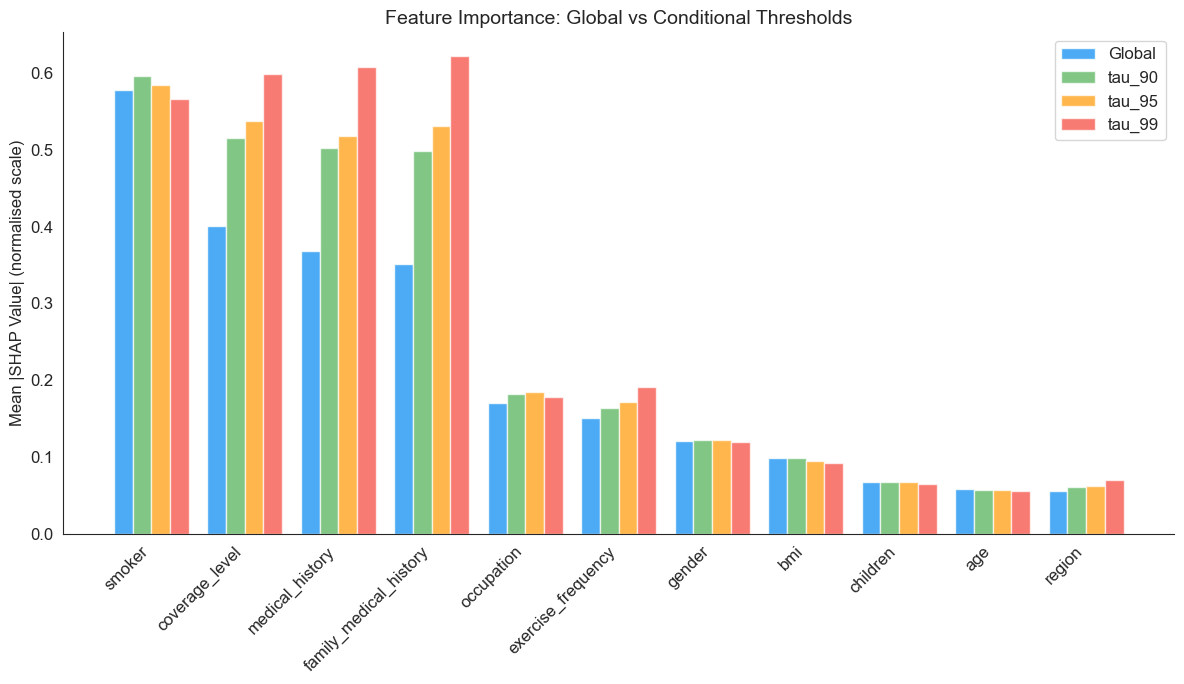

Saved: /Users/baloyithabangbonganijunior/Downloads/chapter3_figures/fig_shap_threshold_comparison.png


In [31]:
# --- Figure: Threshold Comparison (Global vs Conditional importance ranking) ---
fig, ax = plt.subplots(figsize=(12, 7))

x_pos = np.arange(len(RAW_VARS))
width = 0.2

# Sort by global importance
global_order = df_global_shap.sort_values('Mean |SHAP|', ascending=False)['Variable'].tolist()

# Global bars
global_vals = [df_global_shap.loc[df_global_shap['Variable'] == v, 'Mean |SHAP|'].values[0]
               for v in global_order]
ax.bar(x_pos - 1.5 * width, global_vals, width, label='Global',
       color='#2196F3', alpha=0.8)

# Conditional bars
cond_colours = {'tau_90': '#4CAF50', 'tau_95': '#FF9800', 'tau_99': '#F44336'}
for i, name in enumerate(['tau_90', 'tau_95', 'tau_99']):
    df_c = conditional_results[name]
    vals = [df_c.loc[df_c['Variable'] == v, 'Cond Mean |SHAP|'].values[0]
            for v in global_order]
    ax.bar(x_pos + (i - 0.5) * width, vals, width, label=name,
           color=cond_colours[name], alpha=0.7)

ax.set_xticks(x_pos)
ax.set_xticklabels(global_order, rotation=45, ha='right')
ax.set_ylabel('Mean |SHAP Value| (normalised scale)')
ax.set_title('Feature Importance: Global vs Conditional Thresholds')
ax.legend()
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(FIG_DIR + 'fig_shap_threshold_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}fig_shap_threshold_comparison.png')

## 10. Summary Tables and Exports

In [32]:
# --- MC Summary Table ---
mc_summary_df = pd.DataFrame([mc_summary])
mc_summary_path = FIG_DIR + 'mc_summary.csv'
mc_summary_df.to_csv(mc_summary_path, index=False)
print(f'MC summary saved: {mc_summary_path}')
print(mc_summary_df.to_string(index=False, float_format='%.2f'))

print()

MC summary saved: /Users/baloyithabangbonganijunior/Downloads/chapter3_figures/mc_summary.csv
    Mean      SD  Skewness  Kurtosis     Min      P25   Median      P75      P90      P95      P99      Max
16707.47 4409.38      0.13     -0.30 5171.76 13611.58 16632.23 19694.08 22482.35 24153.90 27160.30 31466.49



In [33]:
# --- SHAP Importance Table (Global + Conditional) ---
shap_table = df_global_shap[['Variable', 'Mean Signed SHAP', 'Mean |SHAP|']].copy()

for name in ['tau_90', 'tau_95', 'tau_99']:
    df_c = conditional_results[name]
    shap_table = shap_table.merge(
        df_c[['Variable', 'Cond Mean Signed', 'Cond Mean |SHAP|']].rename(
            columns={
                'Cond Mean Signed': f'Signed ({name})',
                'Cond Mean |SHAP|': f'|SHAP| ({name})'
            }),
        on='Variable', how='left'
    )

shap_table_path = FIG_DIR + 'shap_importance_table.csv'
shap_table.to_csv(shap_table_path, index=False)
print(f'SHAP importance table saved: {shap_table_path}')
print(shap_table.to_string(index=False, float_format='%.6f'))

SHAP importance table saved: /Users/baloyithabangbonganijunior/Downloads/chapter3_figures/shap_importance_table.csv
              Variable  Mean Signed SHAP  Mean |SHAP|  Signed (tau_90)  |SHAP| (tau_90)  Signed (tau_95)  |SHAP| (tau_95)  Signed (tau_99)  |SHAP| (tau_99)
                smoker          0.022117     0.577085         0.509992         0.596122         0.534664         0.583761         0.553370         0.566311
        coverage_level          0.020142     0.401242         0.406407         0.515254         0.483113         0.537199         0.592844         0.598761
       medical_history         -0.030392     0.368215         0.352643         0.502082         0.422372         0.518063         0.588652         0.608168
family_medical_history          0.006943     0.351858         0.377915         0.497911         0.432521         0.530644         0.620139         0.621536
            occupation          0.011241     0.170456         0.067879         0.182541         0.087789

In [34]:
# --- MC Convergence Table ---
convergence_path = FIG_DIR + 'mc_convergence.csv'
df_conv.to_csv(convergence_path, index=False)
print(f'MC convergence table saved: {convergence_path}')

# --- High-Cost Threshold Summary ---
hc_rows = []
for name, tau in thresholds.items():
    hc_rows.append({
        'Threshold': name,
        'Tau': tau,
        'u (R)': u_vals[name],
        'n(H)': int(h_sets[name].sum()),
        'Proportion': h_sets[name].sum() / B
    })

df_hc_summary = pd.DataFrame(hc_rows)
hc_path = FIG_DIR + 'highcost_thresholds.csv'
df_hc_summary.to_csv(hc_path, index=False)
print(f'High-cost thresholds saved: {hc_path}')
print(df_hc_summary.to_string(index=False))

MC convergence table saved: /Users/baloyithabangbonganijunior/Downloads/chapter3_figures/mc_convergence.csv
High-cost thresholds saved: /Users/baloyithabangbonganijunior/Downloads/chapter3_figures/highcost_thresholds.csv
Threshold  Tau        u (R)  n(H)  Proportion
   tau_90 0.90 22482.351562  1000        0.10
   tau_95 0.95 24153.904297   500        0.05
   tau_99 0.99 27160.304688   100        0.01


In [35]:
# --- Export simulated profiles with predictions and SHAP values ---
df_export = df_mc.copy()
df_export['predicted_cost'] = y_mc
df_export['predicted_cost_augmented'] = y_mc_augmented

for j, var in enumerate(RAW_VARS):
    df_export[f'shap_{var}'] = shap_values_11[:, j]

export_path = FIG_DIR + 'mc_profiles_with_shap.csv'
df_export.to_csv(export_path, index=False)
print(f'Full export saved: {export_path}')
print(f'Export shape: {df_export.shape}')

Full export saved: /Users/baloyithabangbonganijunior/Downloads/chapter3_figures/mc_profiles_with_shap.csv
Export shape: (10000, 24)


In [36]:
# --- Final Summary ---
print('=' * 70)
print('MONTE CARLO SIMULATION AND SHAPLEY ATTRIBUTION COMPLETE')
print('=' * 70)
print()
print(f'MC Simulation:')
print(f'  Profiles generated (B): {B:,}')
print(f'  Predicted cost range  : R{y_mc.min():,.2f} to R{y_mc.max():,.2f}')
print(f'  Mean predicted cost   : R{y_mc.mean():,.2f}')
print(f'  MCSE                  : R{y_mc.std() / np.sqrt(B):,.2f}')
print(f'  Residual SD (sigma_e) : R{sigma_e:,.2f}')
print()
print(f'SHAP Attribution:')
print(f'  Explainer             : GradientExplainer')
print(f'  Background sample     : 200 training rows')
print(f'  Encoded features      : 22')
print(f'  Aggregated variables  : 11')
print(f'  Efficiency error (max): {efficiency_error.max():.6f}')
print()
print(f'High-Cost Thresholds:')
for name, tau in thresholds.items():
    print(f'  {name}: R{u_vals[name]:>10,.2f} (n={h_sets[name].sum():>4d})')
print()
print(f'Figures generated:')
fig_names = [
    'fig_mc_convergence.png',
    'fig_mc_input_distributions.png',
    'fig_mc_predicted_cost_distribution.png',
    'fig_mc_predicted_vs_actual.png',
    'fig_mc_residual_augmented.png',
    'fig_mc_residual_diagnostics.png',
    'fig_shap_global_importance.png',
    'fig_shap_beeswarm.png',
    'fig_highcost_profile_comparison.png',
    'fig_shap_conditional_importance.png',
    'fig_shap_highcost_waterfall.png',
    'fig_shap_threshold_comparison.png'
]
for fn in fig_names:
    print(f'  - {fn}')
print()
print(f'CSV exports:')
print(f'  - mc_summary.csv')
print(f'  - shap_importance_table.csv')
print(f'  - mc_convergence.csv')
print(f'  - highcost_thresholds.csv')
print(f'  - mc_profiles_with_shap.csv')

MONTE CARLO SIMULATION AND SHAPLEY ATTRIBUTION COMPLETE

MC Simulation:
  Profiles generated (B): 10,000
  Predicted cost range  : R5,171.76 to R31,466.49
  Mean predicted cost   : R16,707.47
  MCSE                  : R44.09
  Residual SD (sigma_e) : R289.42

SHAP Attribution:
  Explainer             : GradientExplainer
  Background sample     : 200 training rows
  Encoded features      : 22
  Aggregated variables  : 11
  Efficiency error (max): 0.377866

High-Cost Thresholds:
  tau_90: R 22,482.35 (n=1000)
  tau_95: R 24,153.90 (n= 500)
  tau_99: R 27,160.30 (n= 100)

Figures generated:
  - fig_mc_convergence.png
  - fig_mc_input_distributions.png
  - fig_mc_predicted_cost_distribution.png
  - fig_mc_predicted_vs_actual.png
  - fig_mc_residual_augmented.png
  - fig_mc_residual_diagnostics.png
  - fig_shap_global_importance.png
  - fig_shap_beeswarm.png
  - fig_highcost_profile_comparison.png
  - fig_shap_conditional_importance.png
  - fig_shap_highcost_waterfall.png
  - fig_shap_thres